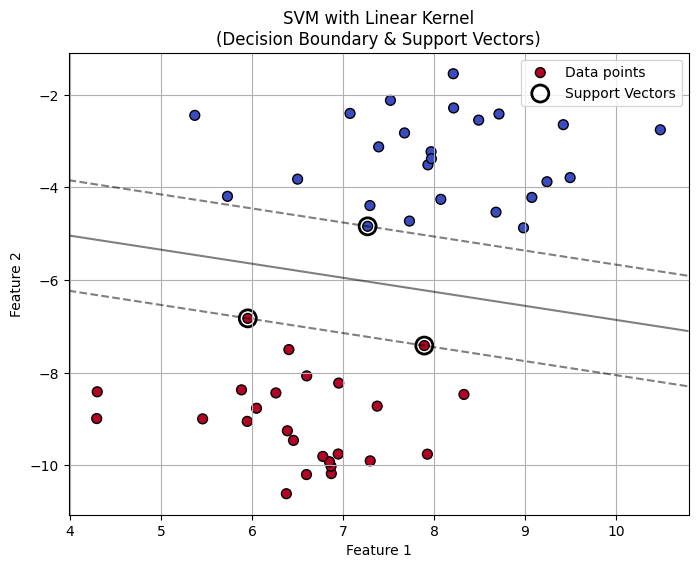

Support vectors:
 [[ 7.27059007 -4.84225716]
 [ 5.95313618 -6.82945967]
 [ 7.89359985 -7.41655113]]
Support vector indices: [24  7 29]


In [1]:
# === 1. Import libraries ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# === 2. Create simple 2D classification data ===
X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=1.0)

# === 3. Train an SVM classifier ===
model = SVC(kernel='linear')  # Linear SVM
model.fit(X, y)

# === 4. Plotting ===
plt.figure(figsize=(8,6))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=50, edgecolors='k', label='Data points')

# Plot the support vectors
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', linewidths=2, label='Support Vectors')

# Plot the decision boundary (hyperplane)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# Draw decision boundary and margins
ax.contour(XX, YY, Z, colors='k',
           levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Add labels and show
plt.title("SVM with Linear Kernel\n(Decision Boundary & Support Vectors)")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# === 5. Print Support Vectors (Optional) ===
print("Support vectors:\n", model.support_vectors_)
print("Support vector indices:", model.support_)
